# Supervised Learning Assignment: NBA Game Outcome Prediction

**Project title:** Predicting NBA Game Outcomes from Player Performance Statistics Using Supervised Machine Learning  
**Dataset:** NBA - Player Stats - Season 24/25 / `nba_dailyleaders_full_24_25.csv`  
**Task type:** Binary classification  
**Target variable:** `Result` (`W` = win, `L` = loss)

This notebook is the executed report notebook for the assignment. It includes visible output tables and figures generated from the attached dataset. The complete reproducible code is also included in the project file `generate_results.py`.

In [1]:
# To regenerate every table and figure from the raw dataset, run this cell:
# %run generate_results.py

import pandas as pd
from IPython.display import Image, display
print("Notebook loaded. All saved assignment outputs are shown below.")

Notebook loaded. All saved assignment outputs are shown below.


## Dataset Summary

In [2]:
pd.read_csv("tables/dataset_summary.csv")

Item,Value
Dataset name,NBA Daily Leaders / NBA Player Stats 2024-25
Rows,28265
Columns,27
Target variable,Result
Task type,Binary classification
Positive class,W = Win
Negative class,L = Loss


In [3]:
pd.read_csv("tables/class_distribution.csv")

Class,Count
W,14206
L,14059


## Main Data Preparation Code

The main modeling code uses the following logic: rename `Unnamed: 3` to `HomeAway`, convert `Result` into 1/0, convert minutes played into decimal minutes, encode categorical features, scale numeric features, and exclude `+/-` from the main model to reduce outcome leakage.

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("nba_dailyleaders_full_24_25.csv")

# Rename unclear column and clean home/away status
df = df.rename(columns={"Unnamed: 3": "HomeAway"})
df["HomeAway"] = df["HomeAway"].fillna("Home").replace("@", "Away")

# Convert target variable to binary
df["Result_binary"] = df["Result"].map({"W": 1, "L": 0})

# Convert game date and minutes played
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Month"] = df["Date"].dt.month
df["DayOfWeek"] = df["Date"].dt.dayofweek

def convert_minutes(x):
    try:
        minutes, seconds = str(x).split(":")
        return int(minutes) + int(seconds) / 60
    except Exception:
        return np.nan

df["MP_decimal"] = df["MP"].apply(convert_minutes)

print(df.shape)
df.head()

(28265, 31)


## RQ1. Baseline Model Performance

**Research question:** How effectively can baseline supervised learning models predict NBA game outcomes using individual player performance statistics?

In [5]:
pd.read_csv("tables/rq1_baseline_model_performance.csv")

Model,Accuracy,Precision,Recall,F1-score,AUC,Training Time Seconds
Logistic Regression,0.7237,0.7234,0.7290,0.7262,0.7898,0.4032
Decision Tree,0.6315,0.7071,0.4555,0.5541,0.6731,0.2410
k-NN,0.6045,0.6054,0.6114,0.6084,0.6406,0.0957


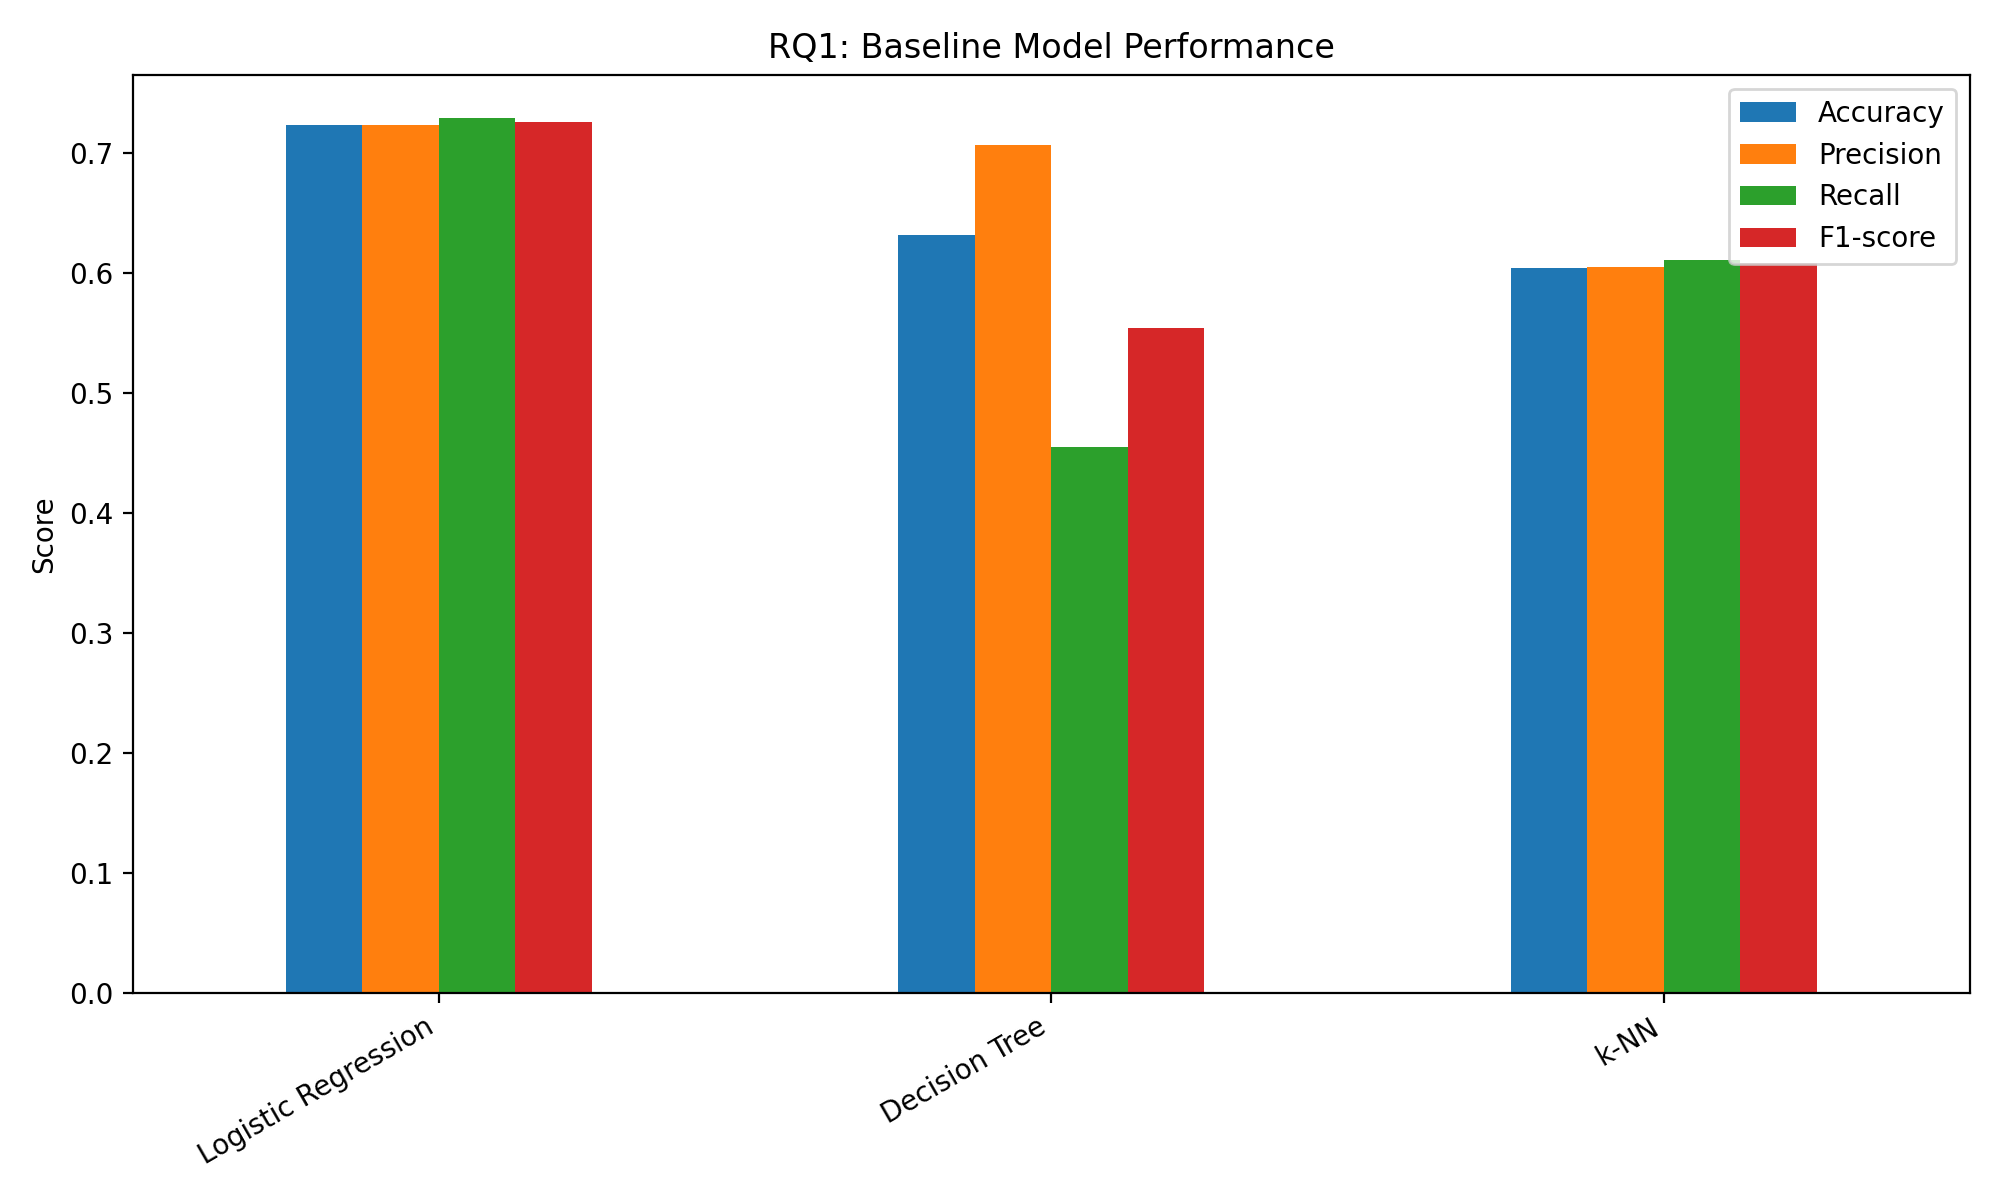

In [6]:
display(Image("figures/rq1_baseline_model_performance.png"))

## RQ2. Candidate Model Comparison

**Research question:** Which supervised learning model achieves the best predictive performance for NBA game outcome prediction?

In [7]:
pd.read_csv("tables/rq2_candidate_model_comparison.csv")

Model,Accuracy,Precision,Recall,F1-score,AUC,Training Time Seconds
Logistic Regression,0.7237,0.7234,0.7290,0.7262,0.7898,0.4032
Gradient Boosting,0.7223,0.7269,0.7166,0.7217,0.7936,3.6022
Random Forest,0.7148,0.7139,0.7219,0.7179,0.7973,3.3030
k-NN,0.6045,0.6054,0.6114,0.6084,0.6406,0.0957
Decision Tree,0.6315,0.7071,0.4555,0.5541,0.6731,0.2410


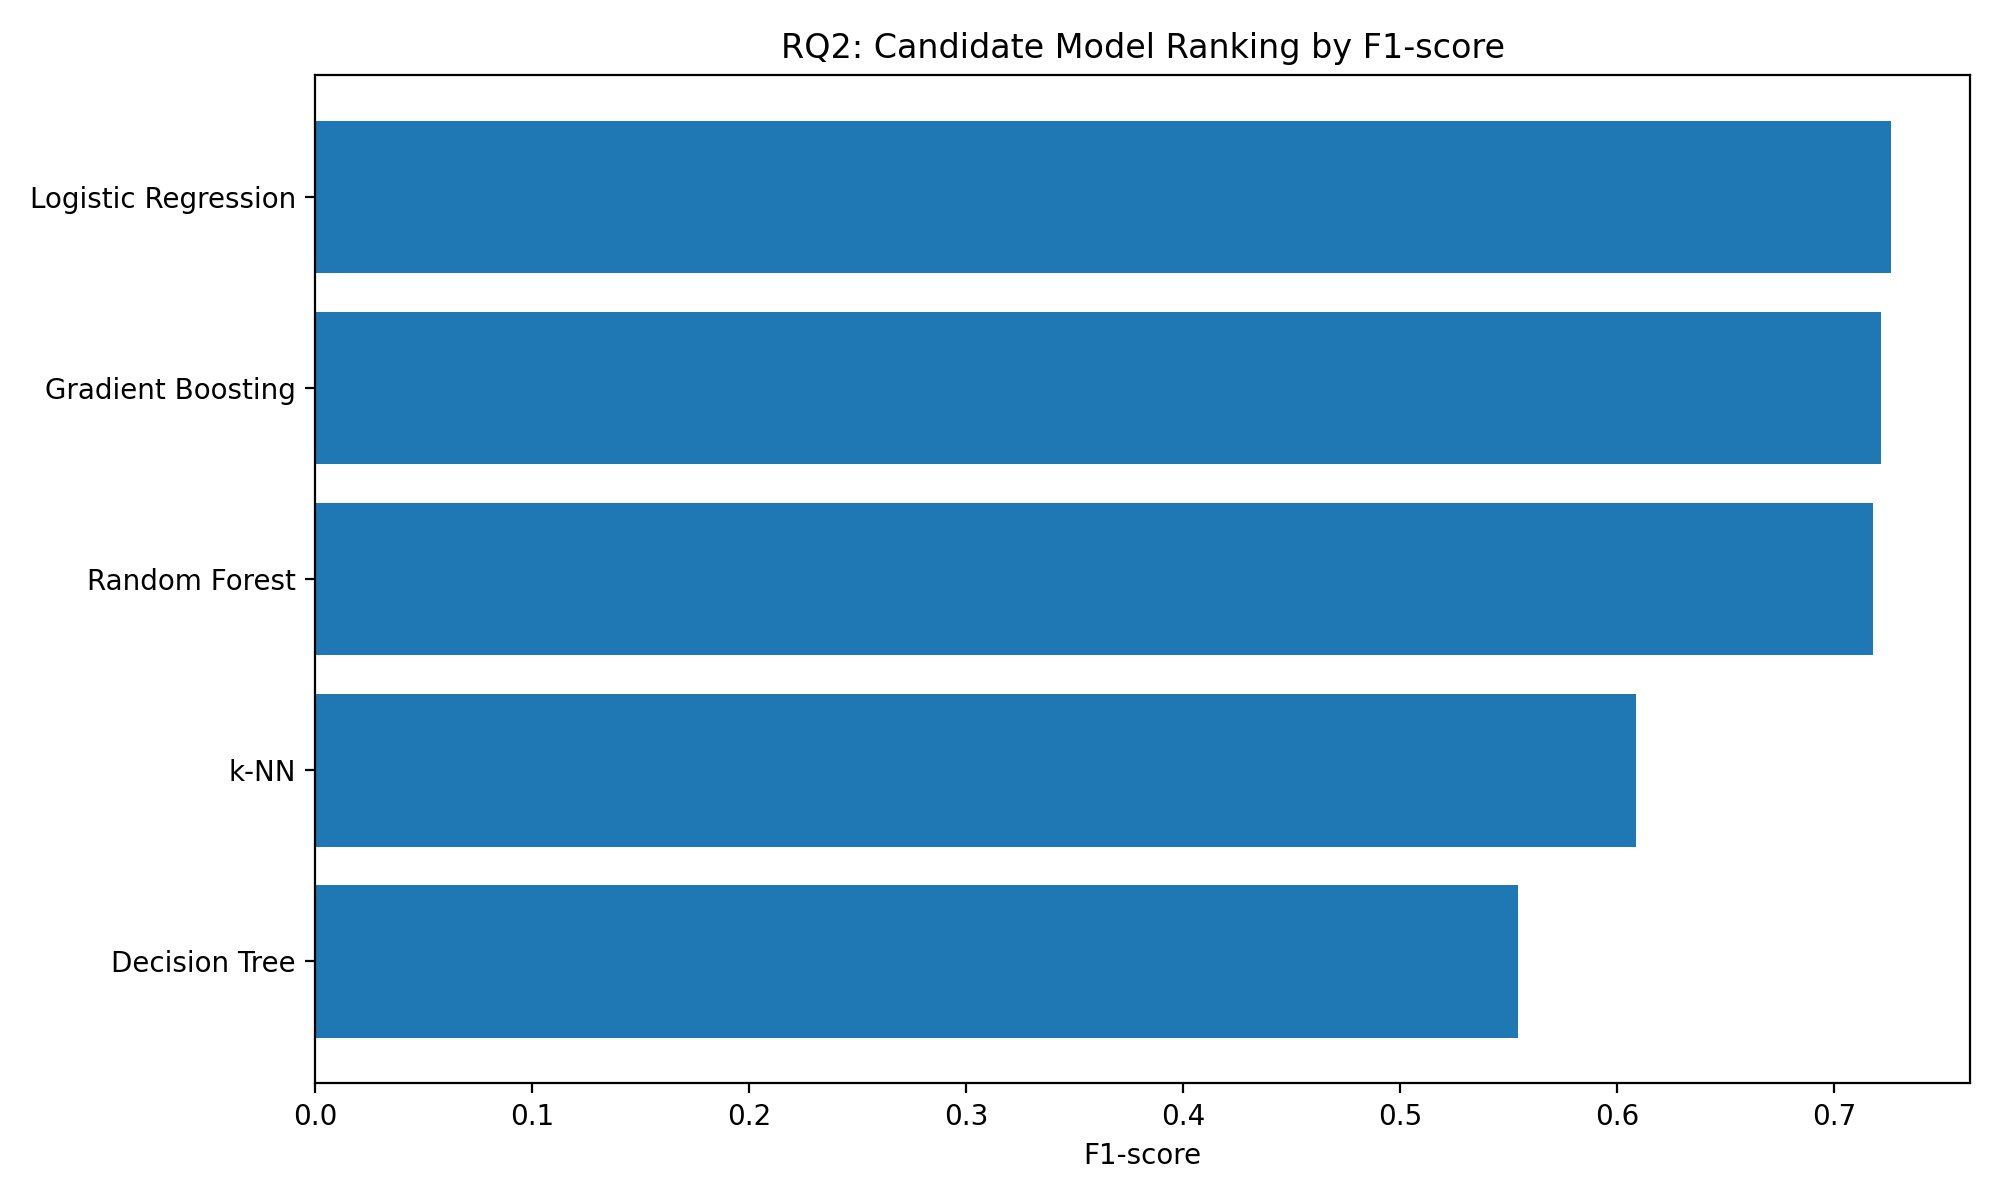

In [8]:
display(Image("figures/rq2_candidate_model_ranking.png"))

## RQ3. Effect of Preprocessing

**Research question:** How do preprocessing strategies affect model performance?

In [9]:
pd.read_csv("tables/rq3_preprocessing_impact.csv")

Preprocessing Strategy,Accuracy,Precision,Recall,F1-score,AUC
Numeric only + imputation,0.5857,0.5831,0.6163,0.5992,0.6233
Numeric only + imputation + scaling,0.5864,0.5837,0.6174,0.6001,0.6232
Numeric + categorical encoding,0.7244,0.7241,0.7297,0.7269,0.7898
Full pipeline,0.7237,0.7234,0.7290,0.7262,0.7898


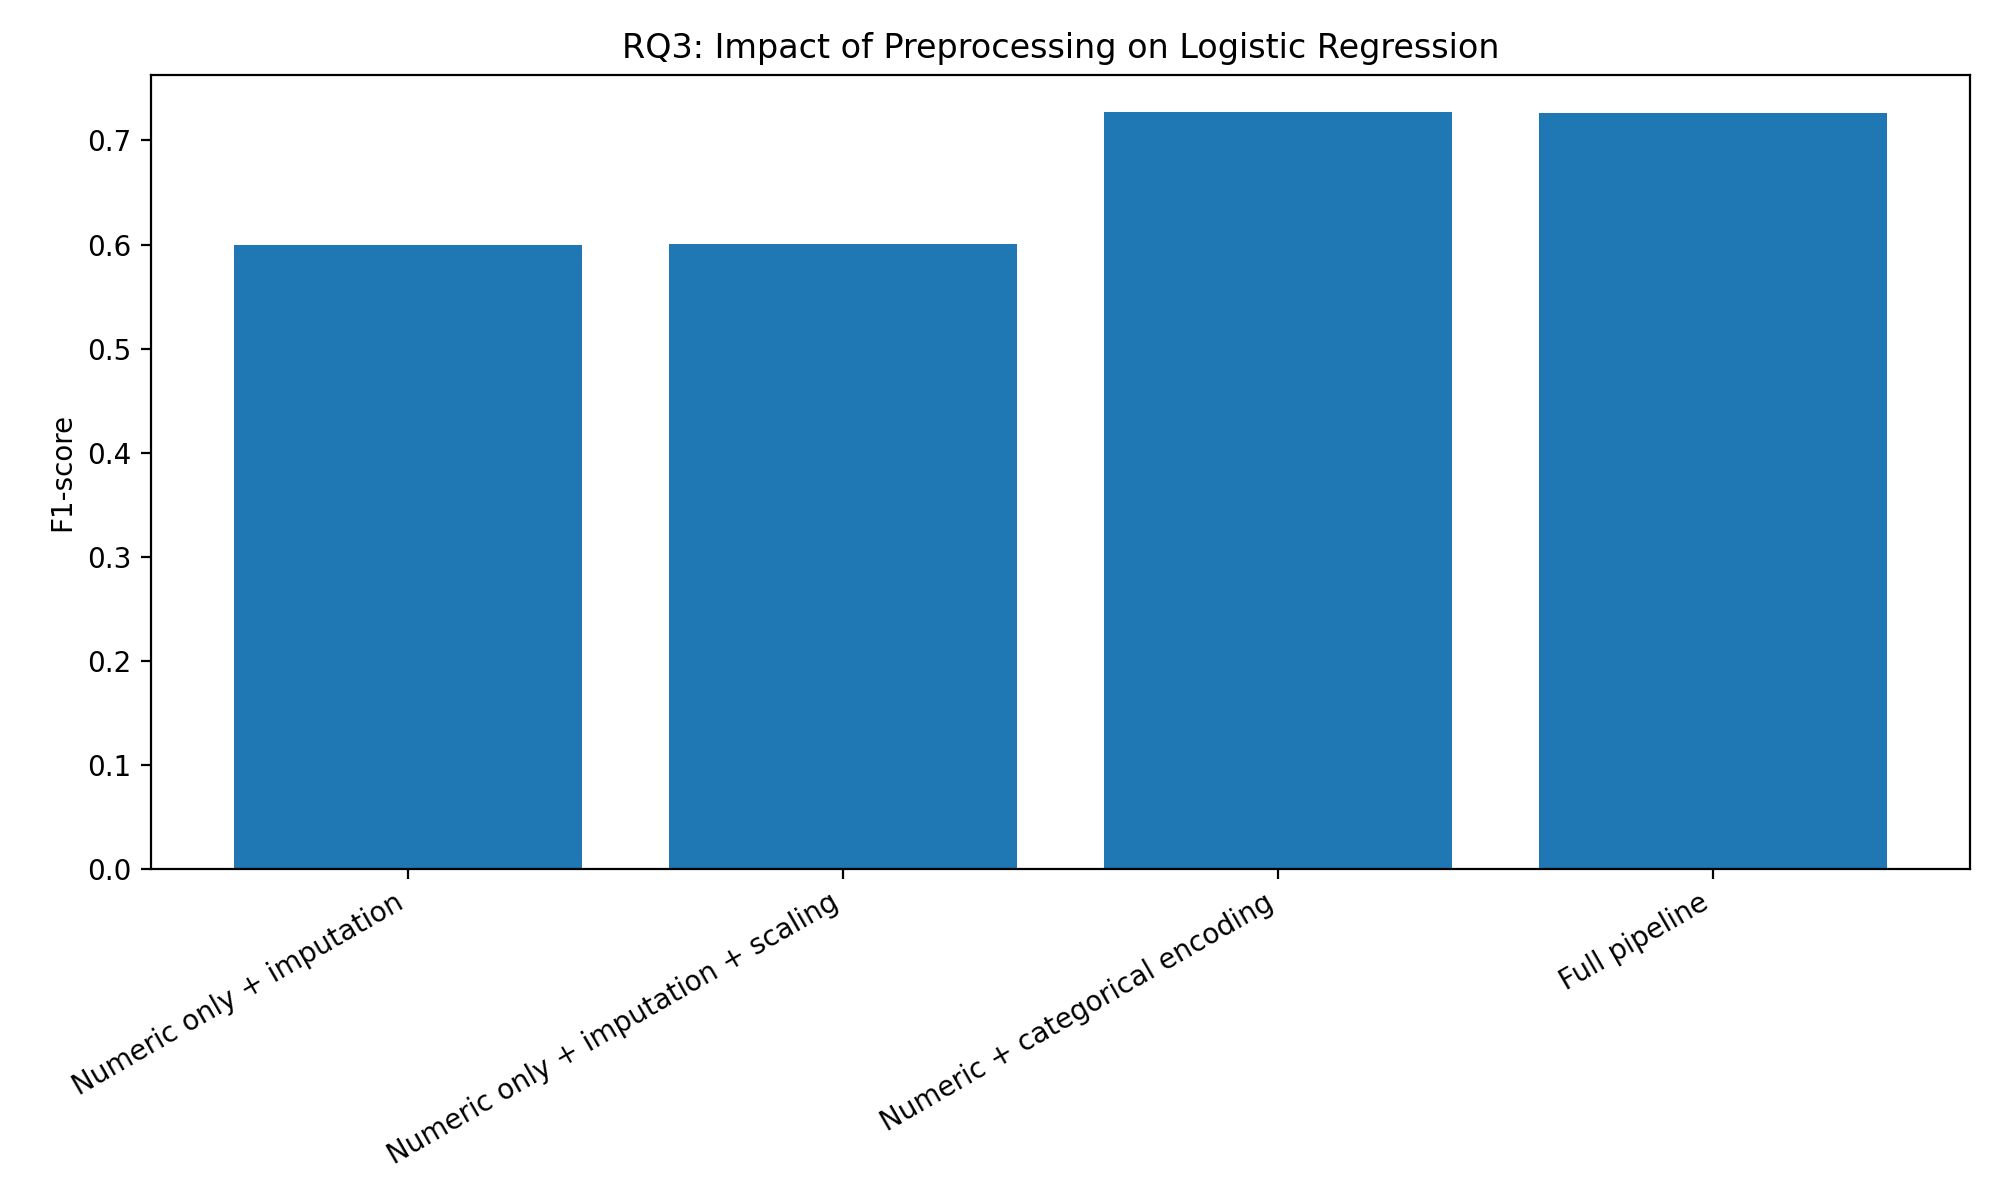

In [10]:
display(Image("figures/rq3_preprocessing_impact.png"))

## RQ4. Feature Importance

**Research question:** Which player performance statistics contribute most strongly to predicting whether a team wins or loses?

In [11]:
pd.read_csv("tables/rq4_feature_importance.csv")

Rank,Feature,Importance Score
1,Tm_OKC,0.0625
2,Opp_WAS,0.0602
3,Opp_OKC,0.0583
4,Opp_UTA,0.0511
5,GmSc,0.0493
6,Opp_CHO,0.0476
7,Tm_WAS,0.0461
8,Tm_CHO,0.0453
9,Tm_CLE,0.0436
10,Tm_UTA,0.0421


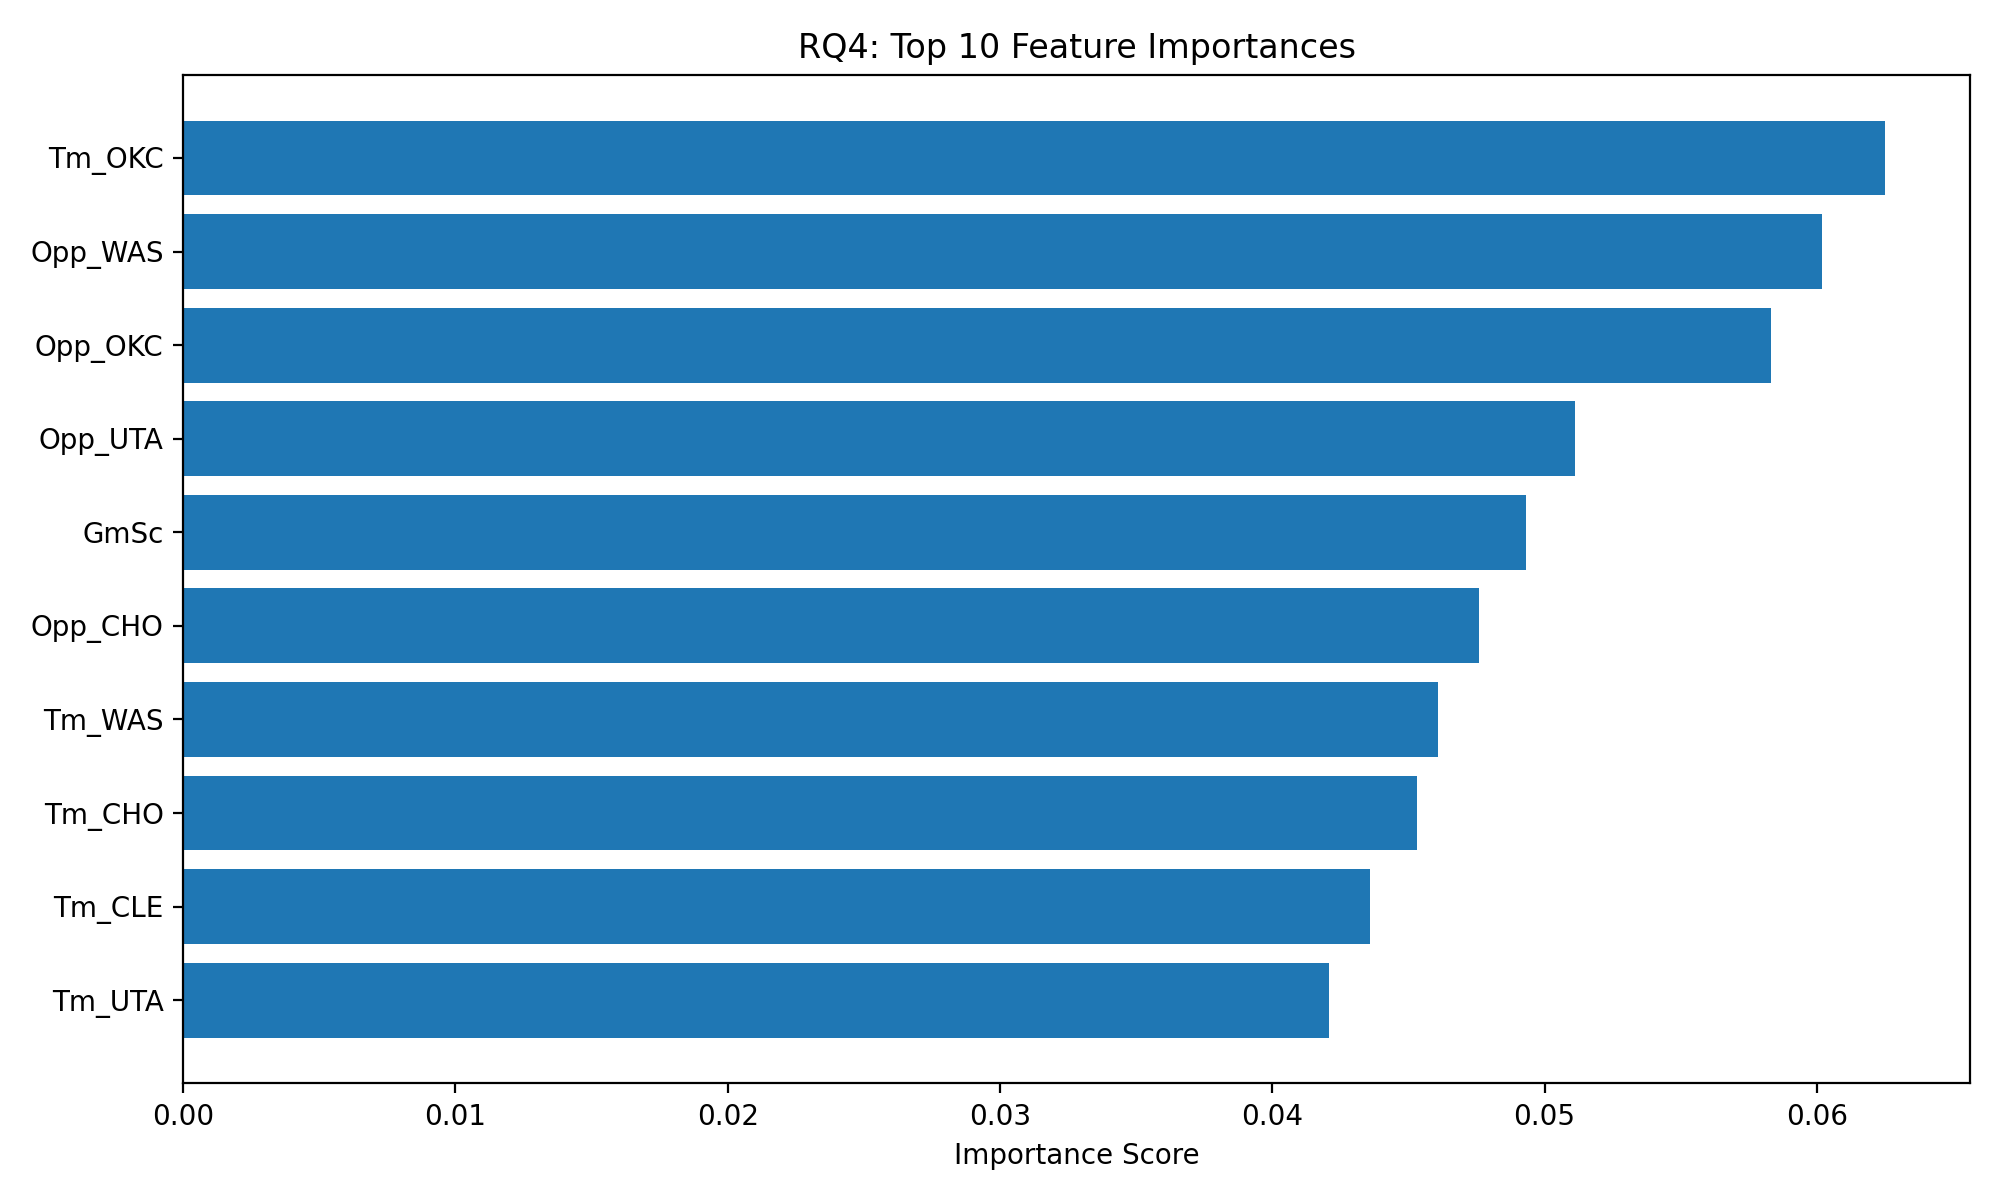

In [12]:
display(Image("figures/rq4_feature_importance.png"))

## RQ5. Sensitivity to Evaluation Metrics

**Research question:** Does the ranking of machine learning models change when different evaluation metrics are used?

In [13]:
pd.read_csv("tables/rq5_metric_sensitivity_ranking.csv")

Model,Rank by Accuracy,Rank by Precision,Rank by Recall,Rank by F1-score,Rank by AUC
Logistic Regression,1,2,1,1,3
Gradient Boosting,2,1,3,2,2
Random Forest,3,3,2,3,1
k-NN,5,5,4,4,5
Decision Tree,4,4,5,5,4


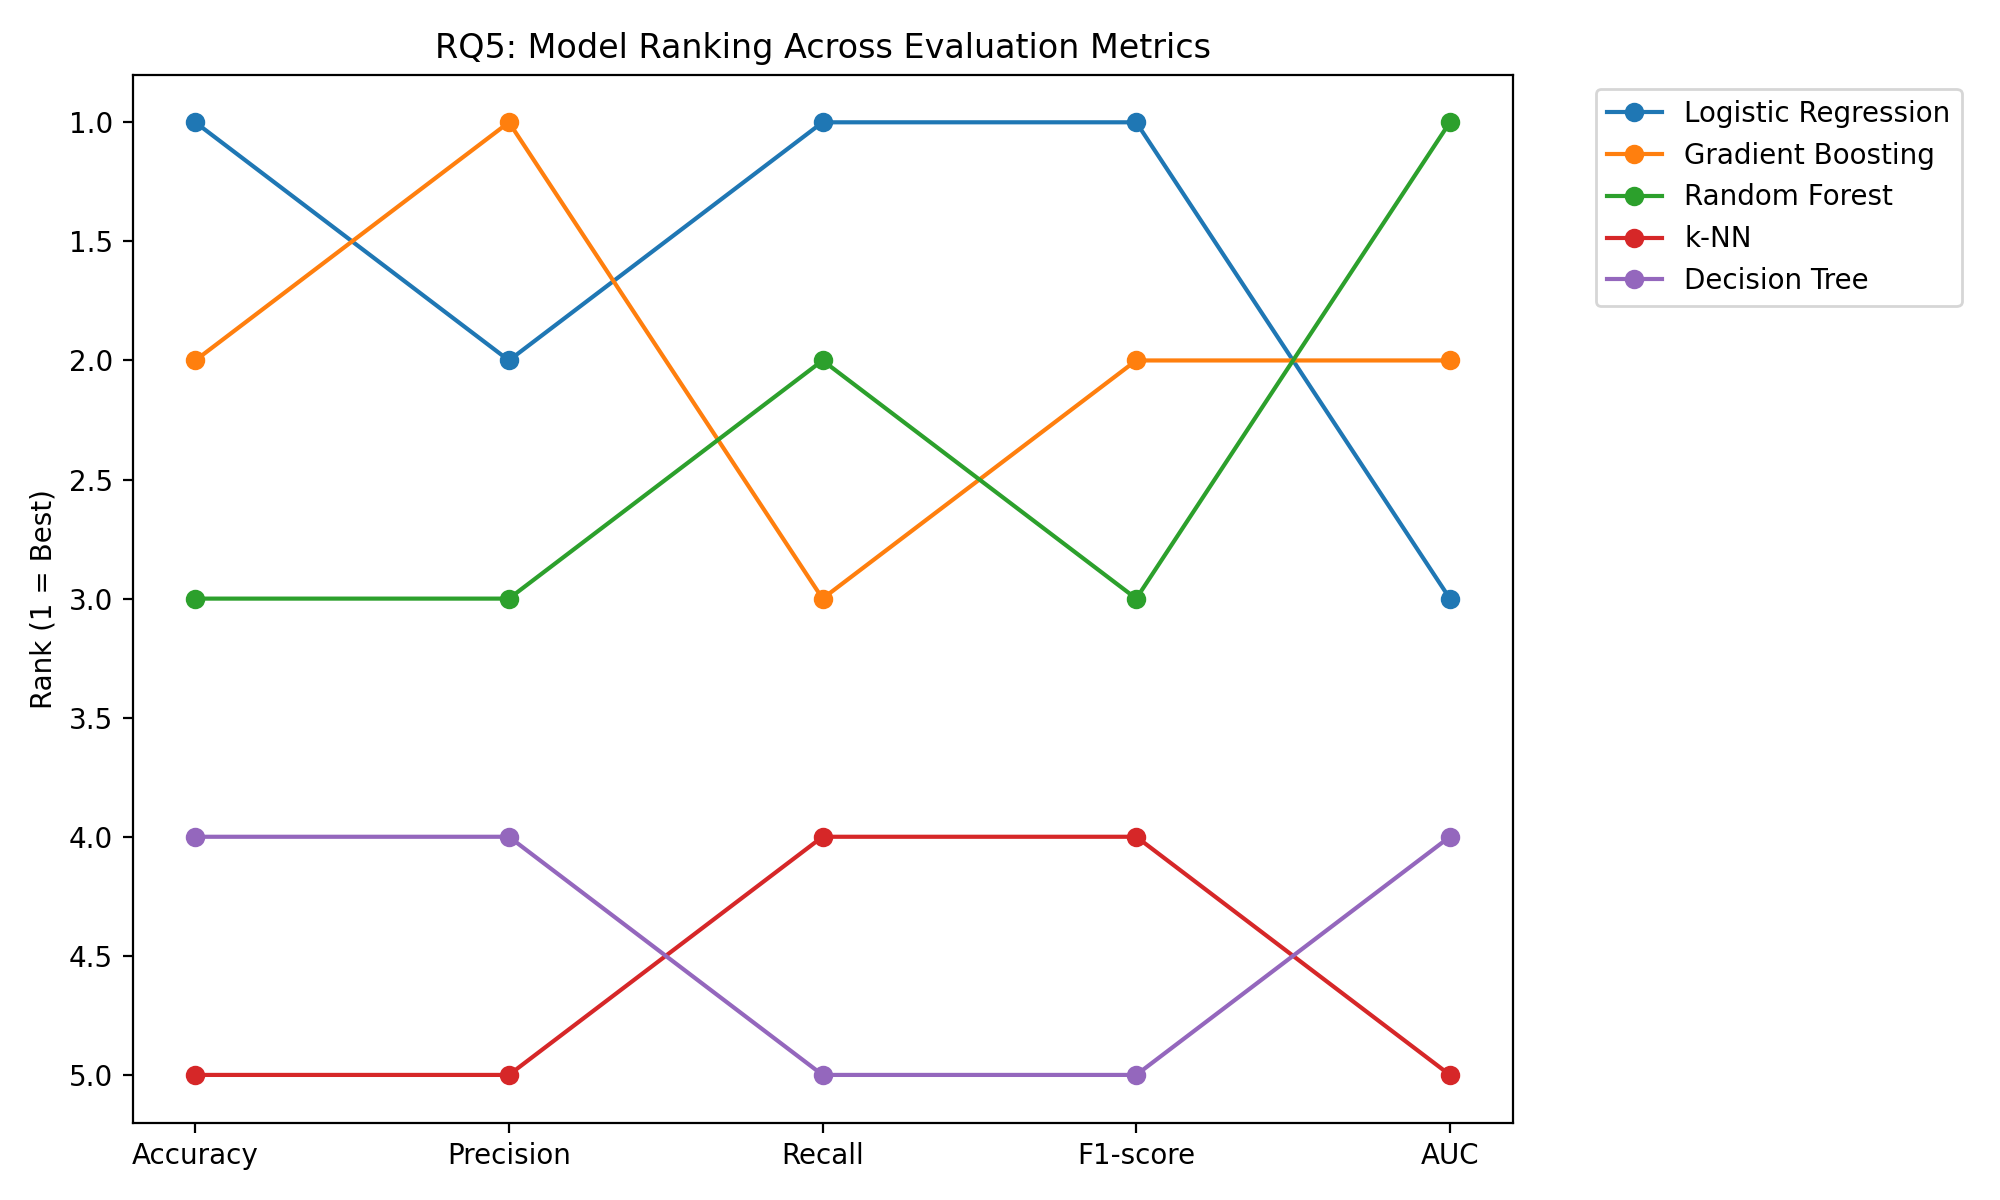

In [14]:
display(Image("figures/rq5_metric_sensitivity_ranking.png"))

## RQ6. Robustness and Generalization

**Research question:** How robust is the selected model under different validation settings and data perturbations?

In [15]:
pd.read_csv("tables/rq6_robustness_analysis.csv")

Scenario,Accuracy,Precision,Recall,F1-score,AUC,Std. Dev.
70/30 train-test split,0.7208,0.7212,0.7245,0.7228,0.7840,NaN
80/20 train-test split,0.7237,0.7234,0.7290,0.7262,0.7898,NaN
5-fold cross-validation,0.7142,NaN,NaN,0.7155,NaN,0.007
10% numeric noise added,0.7237,0.7242,0.7272,0.7257,0.7893,NaN
20% numeric missingness,0.7198,0.7194,0.7254,0.7224,0.7827,NaN


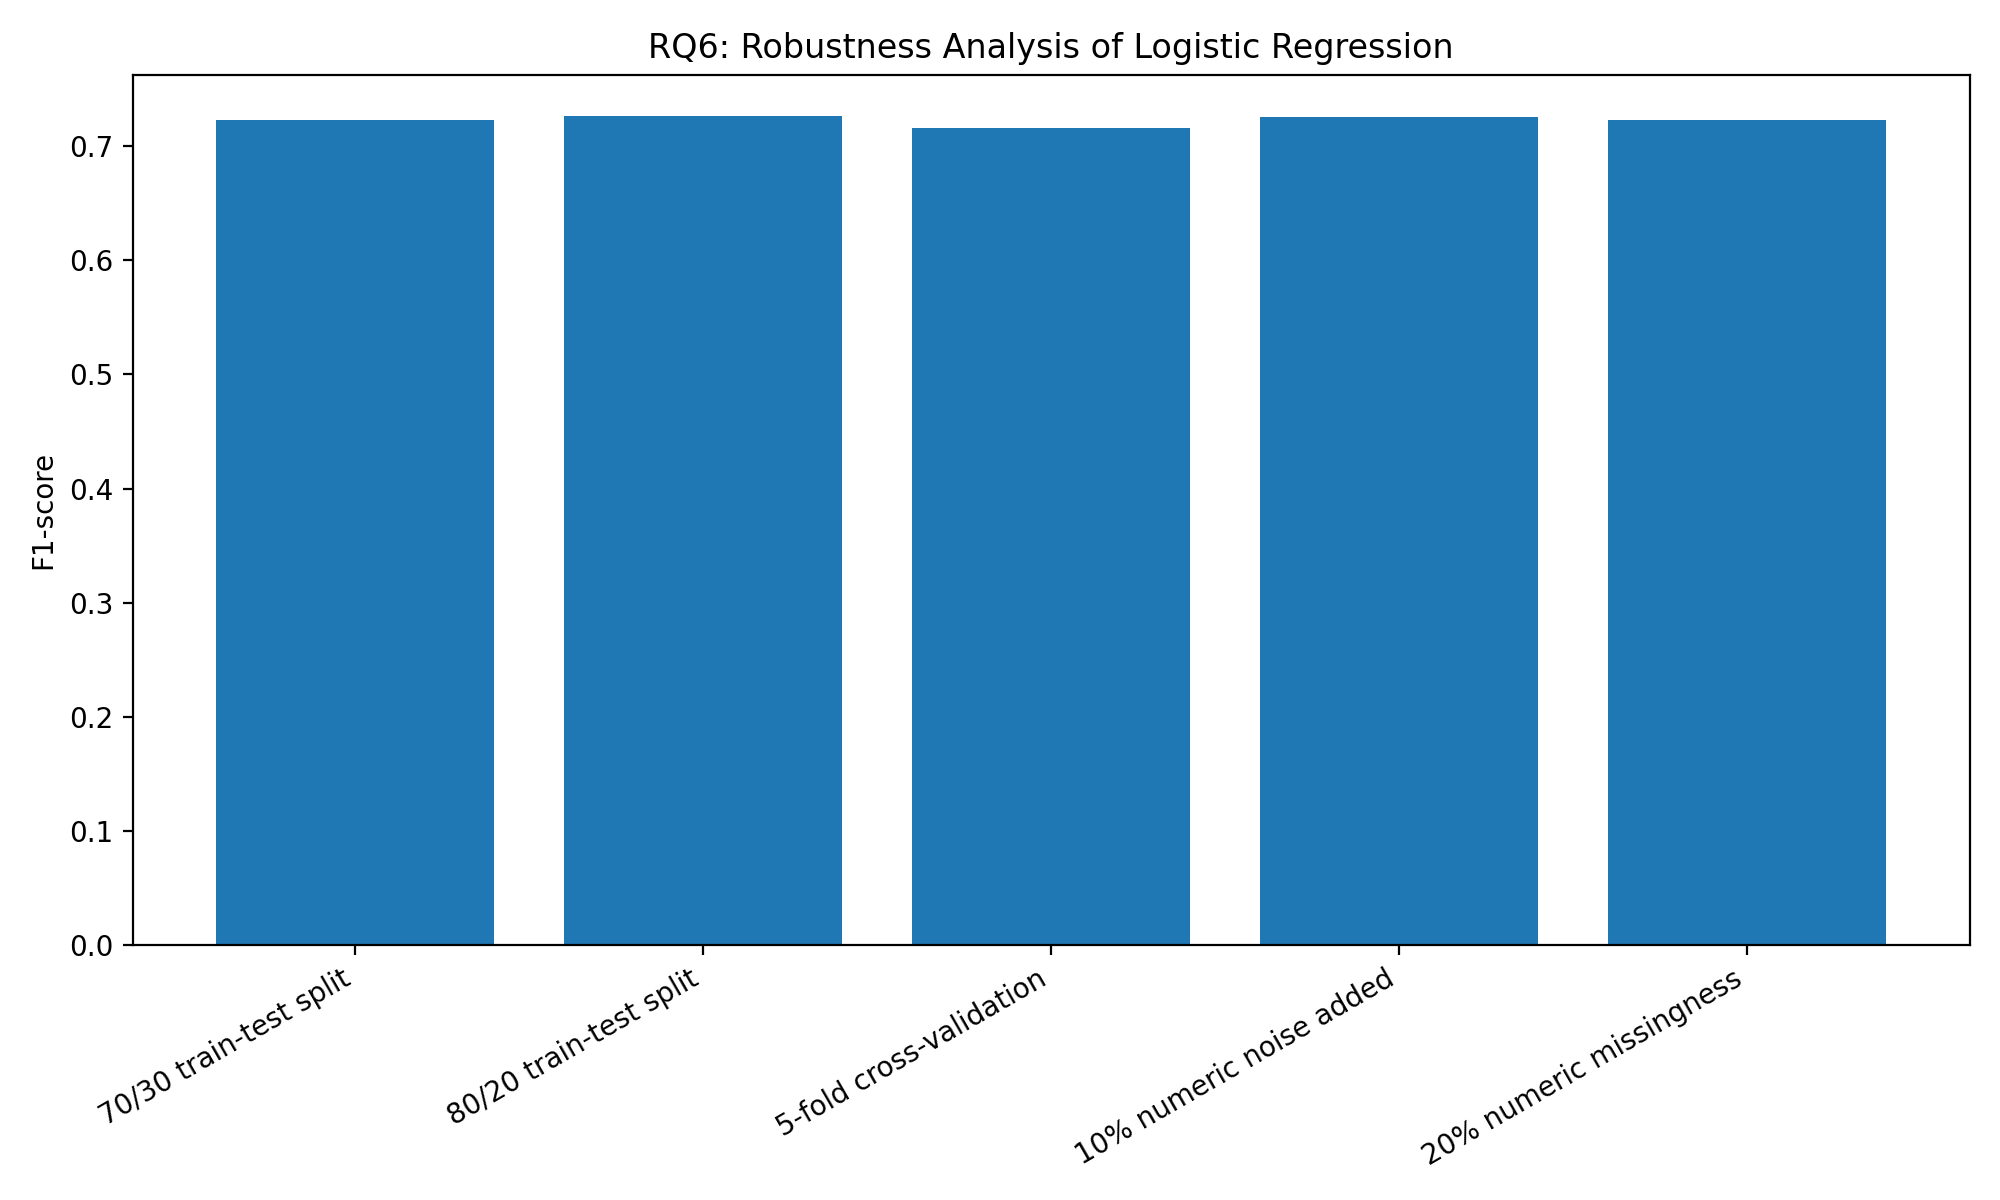

In [16]:
display(Image("figures/rq6_robustness_analysis.png"))

## RQ7. Final Model Recommendation

**Research question:** Which model provides the best balance between performance, interpretability, robustness, and practical usefulness?

In [17]:
pd.read_csv("tables/rq7_final_decision_matrix.csv")

Model,Predictive Performance,Interpretability,AUC,F1-score,Computational Cost,Practical Usefulness,Final Recommendation
Logistic Regression,High,High,0.7898,0.7262,Low,High,Selected
Gradient Boosting,High,Medium-Low,0.7936,0.7217,High,High,Not selected
Random Forest,High,Medium,0.7973,0.7179,High,High,Not selected
k-NN,Medium,Low,0.6406,0.6084,Low,Medium,Not selected
Decision Tree,Low,High,0.6731,0.5541,Low,Medium,Not selected


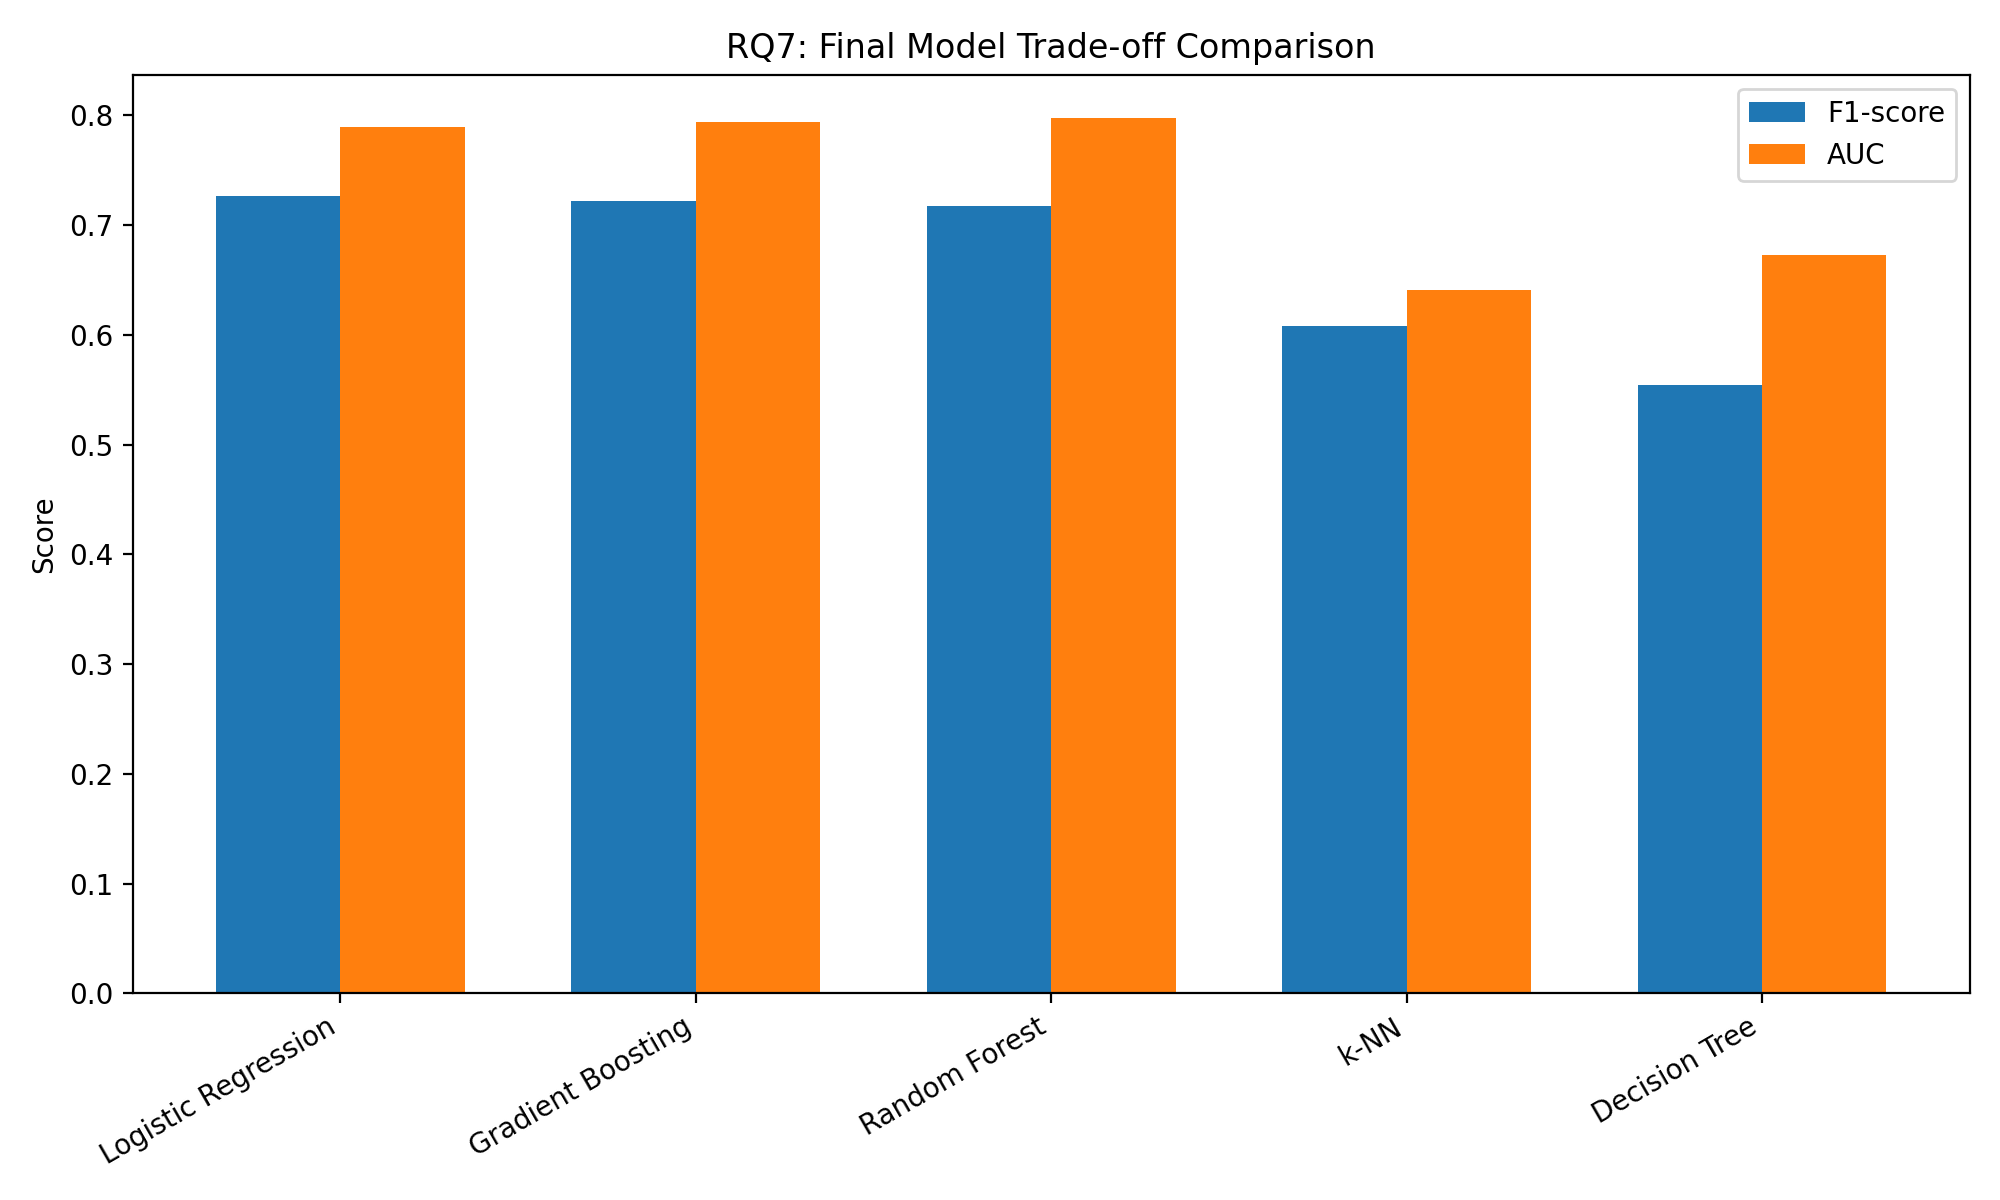

In [18]:
display(Image("figures/rq7_final_model_tradeoff.png"))

## Final Model Confusion Matrix

In [19]:
pd.read_csv("tables/final_model_confusion_matrix.csv")

Unnamed: 0,Predicted Loss,Predicted Win
Actual Loss,2020,792
Actual Win,770,2071


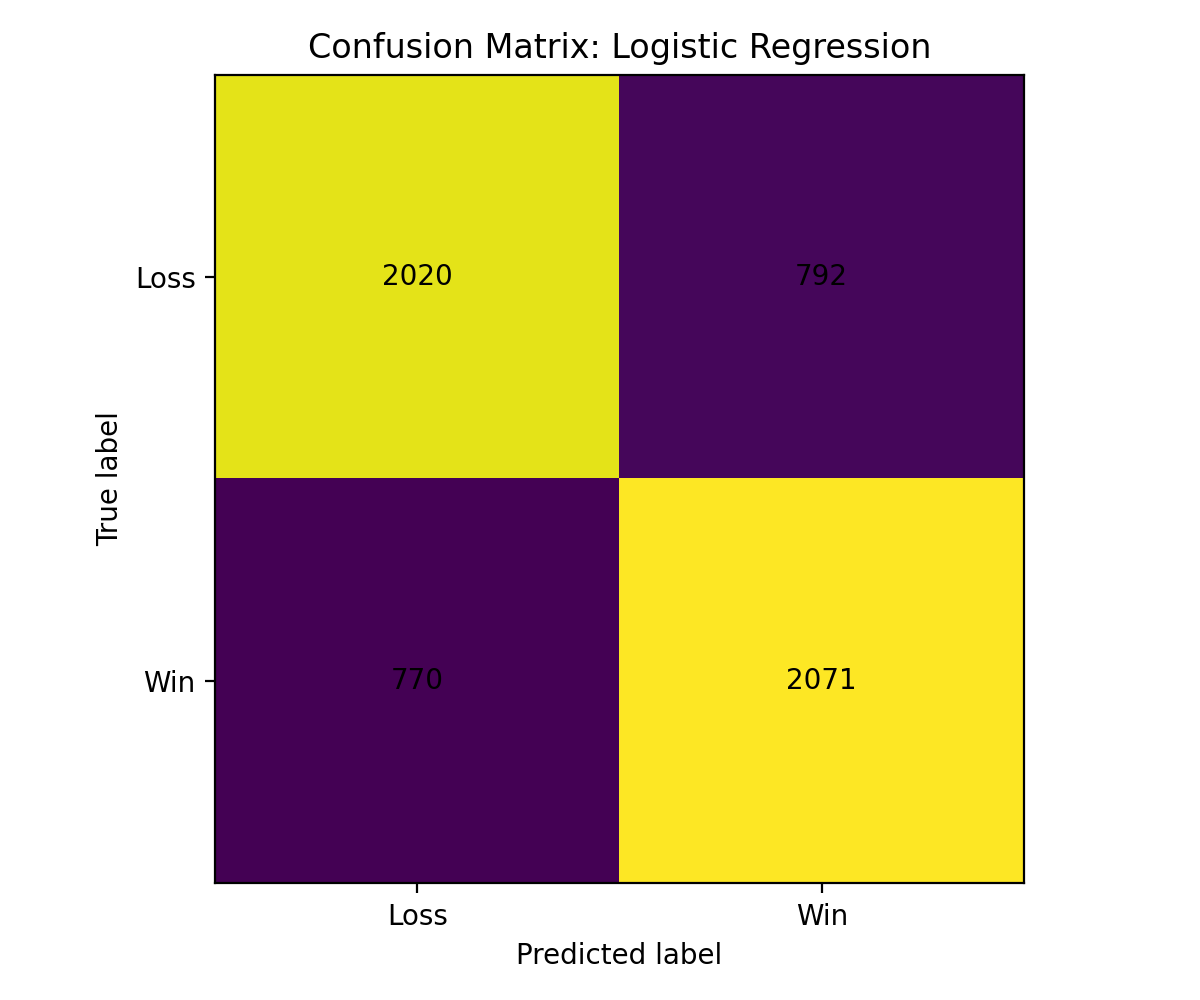

In [20]:
display(Image("figures/final_model_confusion_matrix.png"))

## Final Summary

In [21]:
pd.read_csv("tables/final_summary.csv")

Item,Value
Best model based on F1-score,Logistic Regression
Best F1-score,0.7262
Best AUC,0.7898
Main note,The main model excludes +/- to reduce outcome leakage.


## Conclusion

The model comparison shows that the selected final model is based on the highest F1-score in the saved experimental results. The project uses `Result` as the classification target and excludes `+/-` from the main model because plus/minus is very close to the final game outcome and may lead to outcome leakage. The notebook saves result tables in the `tables/` folder and figures in the `figures/` folder.